# Map observational data onto ISMIP ocean grid

In [1]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta

import scipy.io as sio
import gsw

# Load data

In [14]:
# Directories
data_path="/media/NAS2/ISMIP7/Ocean_Observations_Data"
file = "ISMIP7_SummerCTD.mat"
mat = sio.loadmat(os.path.join(data_path,file))
figure_dir = '../figures'
data_path_share="/media/NAS2/ISMIP7/share_with_modellers"

In [3]:
print(mat.keys())
struct = mat['ISMIP7']

dict_keys(['__header__', '__version__', '__globals__', 'ISMIP7'])


In [4]:
print(struct.dtype.names) 

def struct_to_dict(struct):
    return {name: struct[name][0, 0] for name in struct.dtype.names}

d = struct_to_dict(struct)
print(d.keys())

pib = struct_to_dict(d['pib'])
dotson = struct_to_dict(d['dotson'])

print(pib.keys())
print(dotson.keys())

('pib', 'Pressure', 'Time', 'dotson')
dict_keys(['pib', 'Pressure', 'Time', 'dotson'])
dict_keys(['PT', 'S'])
dict_keys(['PT', 'S'])


In [5]:
def matlab_datenum_to_datetime(datenum):
    return pd.Timestamp('0000-01-01') + pd.to_timedelta(datenum - 1, unit='D')


In [6]:
depth = -1* d['Pressure']
depth

array([[  -5,  -15,  -25,  -35,  -45,  -55,  -65,  -75,  -85,  -95, -105,
        -115, -125, -135, -145, -155, -165, -175, -185, -195, -205, -215,
        -225, -235, -245, -255, -265, -275, -285, -295, -305, -315, -325,
        -335, -345, -355, -365, -375, -385, -395, -405, -415, -425, -435,
        -445, -455, -465, -475, -485, -495, -505, -515, -525, -535, -545,
        -555, -565, -575, -585, -595, -605, -615, -625, -635, -645, -655,
        -665, -675, -685, -695, -705, -715, -725, -735, -745, -755, -765,
        -775, -785, -795, -805, -815, -825, -835, -845, -855, -865, -875,
        -885, -895]], dtype=int32)

In [7]:
## Convert pressure (dbar) to depth (m)
## Note: 1 dbar ≈ 10 kPa
#latitude = -75
#
#depth = gsw.z_from_p(d['Pressure'], latitude)#
#
#depth

In [8]:
pib['PT']#.shape

array([[-1.78214084,         nan,         nan, ...,         nan,
                nan, -0.27595421],
       [-1.78571817,         nan,         nan, ...,         nan,
                nan, -0.31828138],
       [-1.75930247,         nan,         nan, ...,         nan,
                nan, -0.35194622],
       ...,
       [ 1.03160157,         nan,         nan, ...,         nan,
                nan,  1.0794382 ],
       [ 1.03173207,         nan,         nan, ...,         nan,
                nan,  1.08038559],
       [ 1.03184154,         nan,         nan, ...,         nan,
                nan,  1.08132959]])

In [9]:
times = np.array(d['Time'].squeeze())
times_dt = pd.to_datetime(times - 719529, unit='D', origin='unix')

ds_pib = xr.Dataset(
    {"PT": (["depth", "Time"], pib["PT"]),
     "S":  (["depth", "Time"], pib["S"])},
    
    coords={
        "depth": depth.squeeze(),  # .squeeze() removes singleton dimensions
        "pressure": d["Pressure"].squeeze(),
        "Time": times_dt,
    }
)

ds_dotson = xr.Dataset(
    {"PT": (["depth", "Time"], dotson["PT"]),
     "S":  (["depth", "Time"], dotson["S"])},
    
    coords={
        "depth": depth.squeeze(),  # .squeeze() removes singleton dimensions
        "pressure": d["Pressure"].squeeze(),
        "Time": times_dt,
    }
)

In [10]:
ds_pib

<xarray.Dataset> Size: 45kB
Dimensions:   (depth: 90, Time: 31, pressure: 90)
Coordinates:
  * depth     (depth) int32 360B -5 -15 -25 -35 -45 ... -855 -865 -875 -885 -895
  * pressure  (pressure) uint16 180B 5 15 25 35 45 55 ... 855 865 875 885 895
  * Time      (Time) datetime64[ns] 248B 1994-01-01 1995-01-01 ... 2024-01-01
Data variables:
    PT        (depth, Time) float64 22kB -1.782 nan nan nan ... nan nan 1.081
    S         (depth, Time) float64 22kB 33.82 nan nan nan ... nan nan nan 34.68

# Melt rate datasets

In [11]:
# Datasets from publications, provided by P. Dutrieux

PIGtimes=np.array([1994,2007,2009,2010,2012,2014,2016,2019,2020])
PIGmelt=np.array([47.6,98.7,77.9,60.2,31.4,30.4,36.4,60.3,39.8])#in km3/yr
PIGmeltSTD=np.array([9.7,30.2,20.7,7.7,19.7,29.2,17.7,13.9,5.4])

DIStimes=np.array([2000,2006,2007,2009,2011,2012,2014,2016,2018])
DISmelt=np.array([26.2,68.9,39.4,82.5,55.7,23.5,20.5,26.5,17.1])#in km3/yr
DISmeltSTD=np.array([10.1,10.3,22.4,34.7,15.3,10.9,8.5,18,11.9])


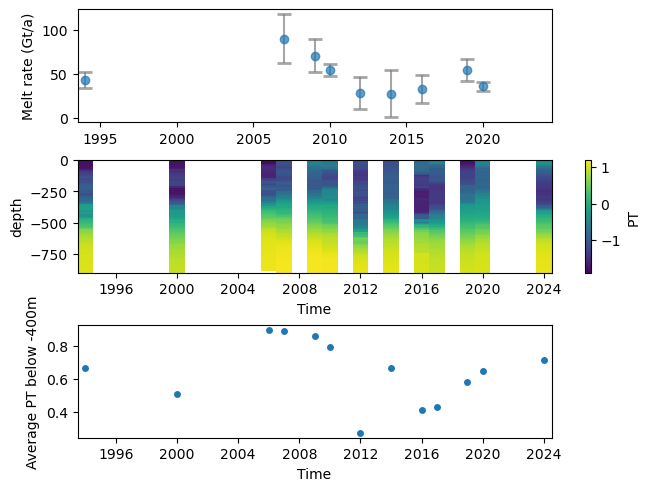

In [15]:
fig, axes = plt.subplots(3, sharex=False,constrained_layout=True)

ax = axes.flatten()[0]

ax.errorbar(PIGtimes, PIGmelt[:]*910/1e3, xerr=None, yerr=PIGmeltSTD[:]*910/1e3, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')

ax.set_xlim(1993.5,2024.5)
ax.set_ylabel('Melt rate (Gt/a)')

ax = axes.flatten()[1]
ds_pib.PT.plot(ax=ax,vmin=-1.9, vmax=1.2)

ax = axes.flatten()[2]

ds_pib.PT.sel(depth=slice(-400,-4000)).mean('depth').plot.scatter()
ax.set_ylabel('Average PT below -400m')
ax.set_xlim([times_dt[0]- timedelta(days=182.5),times_dt[-1]+ timedelta(days=182.5)])

plt.savefig(os.path.join(figure_dir,'PIG.png')) 

plt.show()

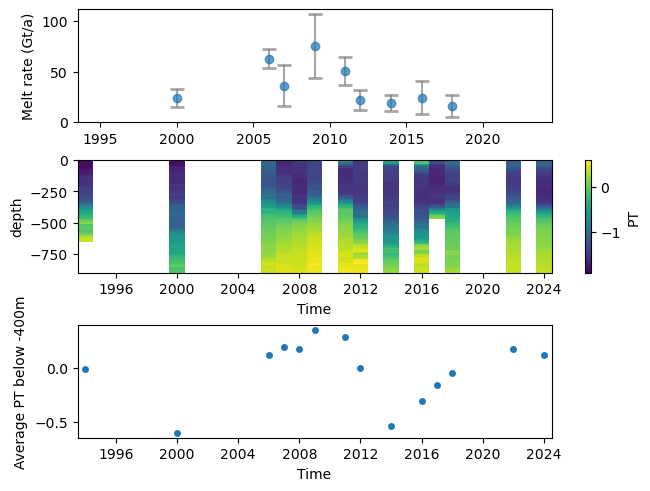

In [16]:
fig, axes = plt.subplots(3, sharex=False,constrained_layout=True)

ax = axes.flatten()[0]

ax.errorbar(DIStimes, DISmelt[:]*910/1e3, xerr=None, yerr=DISmeltSTD[:]*910/1e3, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_xlim(1993.5,2024.5)
ax.set_ylabel('Melt rate (Gt/a)')

ax = axes.flatten()[1]
ds_dotson.PT.plot(ax=ax,vmin=-1.9, vmax=0.6)

ax = axes.flatten()[2]

ds_dotson.PT.sel(depth=slice(-400,-4000)).mean('depth').plot.scatter()
ax.set_ylabel('Average PT below -400m')
ax.set_xlim([times_dt[0]- timedelta(days=182.5),times_dt[-1]+ timedelta(days=182.5)])

plt.savefig(os.path.join(figure_dir,'DIS.png')) 

plt.show()

# Create ocean forcing dataset from this

Create 9 datasets, replace Amundsen Sea with ocean thermal forcing, with a line between 

In [17]:

# load imbie 2 basins
basins = xr.load_dataset(os.path.join(data_path_share, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins = basins.rename({'basinNumber':'basins'}) # basins start at 0


# Load BedMap3
bed = xr.load_dataset(os.path.join(data_path_share, "topography", "bedmap3_ismip_8km.nc"))

# Split basin between PIG and Dotson along Bear Ridge

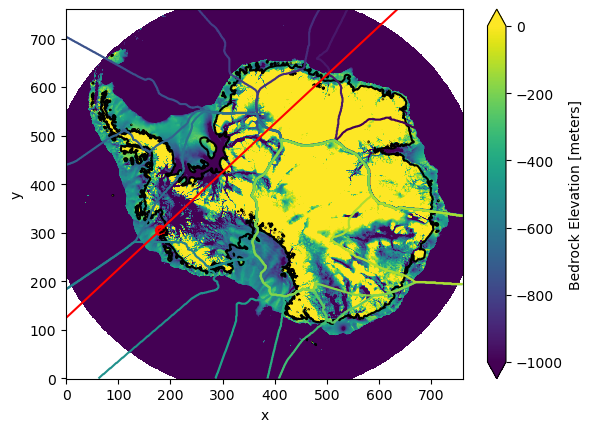

In [19]:
bed.bed.plot(vmin=-1000, vmax=0)
bed.grounded_frac.plot.contour(levels=[0.5], colors=['black'])
plt.contour(basins.basins.values.T, levels=range(17))
plt.scatter(180,305, 50, 'red')
plt.plot(bed.x, (bed.x - 180) + 305, "red")

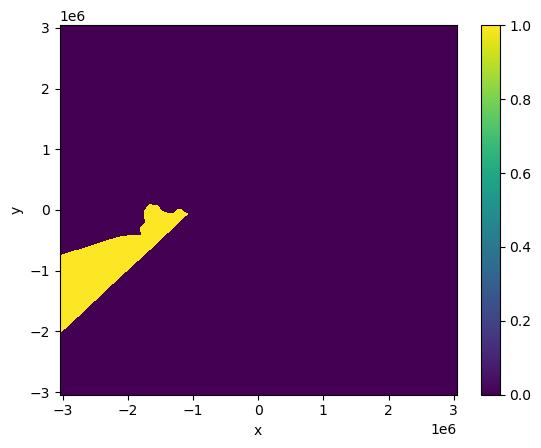

In [20]:
pig = (basins.basins==9) & (((bed.x - 180) + 305) < bed.y)

pig.plot()

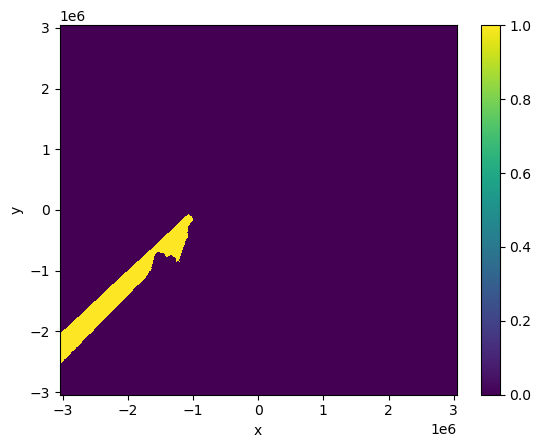

In [21]:
dotson = (basins.basins==9) & (((bed.x - 180) + 305) >= bed.y)

dotson.plot()

# Fill regions with constant profile, match years

In [22]:
# Load climatology

tf = xr.load_dataset(os.path.join(data_path_share, "climatology", "zhou_annual_06_nov","OI_Climatology_ismip8km_60m_tf_extrap.nc"))
salinity = xr.load_dataset(os.path.join(data_path_share, "climatology", "zhou_annual_06_nov","OI_Climatology_ismip8km_60m_so_extrap.nc"))
thetao = xr.load_dataset(os.path.join(data_path_share, "climatology", "zhou_annual_06_nov","OI_Climatology_ismip8km_60m_thetao_extrap.nc"))
 

In [61]:
def calculate_thermal_forcing(dsT,dsS):
    # note that Xylars routine is for SA and CT
    pressure = 1028*9.81*dsT['z']*-1
    
    # Linearisation of freezing point for potential temp, practical salinity from Reese et al., 2018
    a = -0.0572 # deg per PSU
    b = 0.0788 # degC
    c = 7.77e-8 # degC per Pa
    
    pt_freeze = a*dsS+b - c*pressure
    tf = dsT - pt_freeze
    #ds_tf = xr.Dataset({'thermal_forcing': np.squeeze(tf) })
    return tf
    #ds_tf.to_netcdf(dataset+'_TF.nc')

In [72]:
# Temperature
full_depth = thetao["z"]  

for i,year in enumerate(times_dt): 
    print(year.year)
    # check if year exists in melt rates
   
    result_T = xr.full_like(thetao['thetao'], fill_value=np.nan)
    result_S = xr.full_like(salinity['so'], fill_value=np.nan)

    if year.year in PIGtimes:
        print('PIG')
        
        pig_profile_T_interp = ds_pib.PT.sel(Time=year).rename({'depth':'z'}).interp(
            {'z': full_depth},
            method='linear',          # linear between known points
            kwargs={'fill_value': np.nan}  # NaN outside the profile range (don't extrapolate yet)
        )
        pig_profile_T_extrap = (
            pig_profile_T_interp
            .ffill(dim='z')   
            .bfill(dim='z')  
        )

        pig_profile_S_interp = ds_pib.S.sel(Time=year).rename({'depth':'z'}).interp(
            {'z': full_depth},
            method='linear',          # linear between known points
            kwargs={'fill_value': np.nan}  # NaN outside the profile range (don't extrapolate yet)
        )
        pig_profile_S_extrap = (
            pig_profile_S_interp
            .ffill(dim='z')   
            .bfill(dim='z')  
        )
        
        pig_profile_T_3d   = pig_profile_T_extrap.broadcast_like(thetao['thetao'])   # or expand_dims if needed
        pig_profile_S_3d   = pig_profile_S_extrap.broadcast_like(salinity['so'])   # or expand_dims if needed

        result_T = result_T.where(~pig, other=pig_profile_T_3d)
        result_S = result_S.where(~pig, other=pig_profile_S_3d)
        
        #new_thetao['thetao'] = result_T#.rename('thetao')
        #new_so['so'] = result_S#.rename('so')
                
        
    if year.year in DIStimes:
        print('Dotson')
        
        dis_profile_T_interp = ds_dotson.PT.sel(Time=year).rename({'depth':'z'}).interp(
            {'z': full_depth},
            method='linear',          # linear between known points
            kwargs={'fill_value': np.nan}  # NaN outside the profile range (don't extrapolate yet)
        )
        dis_profile_T_extrap = (
            dis_profile_T_interp
            .ffill(dim='z')   
            .bfill(dim='z')  
        )

        dis_profile_S_interp = ds_dotson.S.sel(Time=year).rename({'depth':'z'}).interp(
            {'z': full_depth},
            method='linear',          # linear between known points
            kwargs={'fill_value': np.nan}  # NaN outside the profile range (don't extrapolate yet)
        )
        dis_profile_S_extrap = (
            dis_profile_S_interp
            .ffill(dim='z')   
            .bfill(dim='z')  
        )
        
        dis_profile_T_3d   = dis_profile_T_extrap.broadcast_like(thetao['thetao'])   # or expand_dims if needed
        dis_profile_S_3d   = dis_profile_S_extrap.broadcast_like(salinity['so'])   # or expand_dims if needed

        result_T = result_T.where(~dotson, other=dis_profile_T_3d)
        result_S = result_S.where(~dotson, other=dis_profile_S_3d)
        
    
    
    if year.year in DIStimes or year.year in PIGtimes:

        #new_thetao = xr.full_like(thetao['thetao'], fill_value=np.nan)#.rename('thetao') #thetao.where(basins.basins==9)
        #new_so = xr.full_like(salinity['so'], fill_value=np.nan)#.rename('so') #salinity.where(basins.basins==9)
        
        #new_thetao['thetao'] = result_T#.rename('thetao')
        #new_so['so'] = result_S#.rename('so')
            
        # calculate thermal driving
        new_tf = calculate_thermal_forcing(result_T, result_S)
        
        # save dataset
        result_T.to_dataset(name='thetao').to_netcdf(os.path.join(data_path_share, "parameterisations","Ocean_Observations_Data", "Dutrieux_ismip8km_60m_thetao_"+str(year.year)+".nc"))
        result_S.to_dataset(name='so').to_netcdf(os.path.join(data_path_share, "parameterisations","Ocean_Observations_Data", "Dutrieux_ismip8km_60m_so_"+str(year.year)+".nc"))
        new_tf.to_dataset(name ='tf').to_netcdf(os.path.join(data_path_share, "parameterisations","Ocean_Observations_Data", "Dutrieux_ismip8km_60m_tf_"+str(year.year)+".nc"))
    
    

1994
PIG
1995
1996
1997
1998
1999
2000
Dotson
2001
2002
2003
2004
2005
2006
Dotson
2007
PIG
Dotson
2008
2009
PIG
Dotson
2010
PIG
2011
Dotson
2012
PIG
Dotson
2013
2014
PIG
Dotson
2015
2016
PIG
Dotson
2017
2018
Dotson
2019
PIG
2020
PIG
2021
2022
2023
2024


In [69]:
result_T.to_dataset()

<xarray.Dataset> Size: 79MB
Dimensions:  (y: 761, x: 761, z: 30)
Coordinates:
    lat      (y, x) float64 5MB -51.85 -51.9 -51.94 ... -51.94 -51.9 -51.85
    lon      (y, x) float64 5MB -135.0 -135.1 -135.2 -135.2 ... 44.85 44.92 45.0
  * x        (x) float64 6kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y        (y) float64 6kB -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * z        (z) float64 240B -30.0 -90.0 -150.0 ... -1.71e+03 -1.77e+03
Data variables:
    thetao   (z, y, x) float32 69MB nan nan nan nan nan ... nan nan nan nan nan

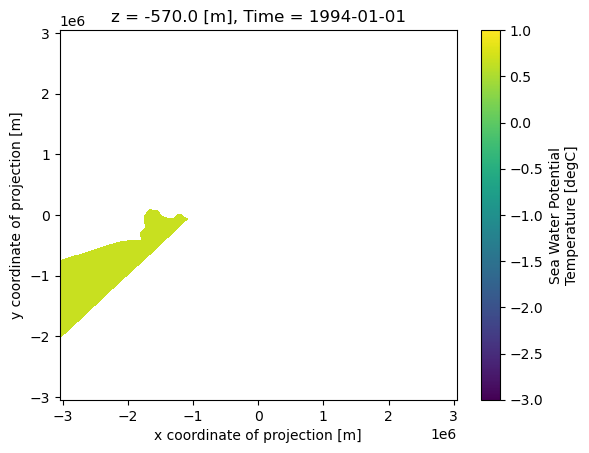

In [48]:
new_thetao.thetao.sel(z=-600, method='nearest').plot(vmin=-3, vmax=1)

In [181]:
ds_pib.sel(Time=year).values

<bound method Mapping.values of <xarray.Dataset> Size: 2kB
Dimensions:   (depth: 90, pressure: 90)
Coordinates:
  * depth     (depth) int32 360B -5 -15 -25 -35 -45 ... -855 -865 -875 -885 -895
  * pressure  (pressure) uint16 180B 5 15 25 35 45 55 ... 855 865 875 885 895
    Time      datetime64[ns] 8B 1994-01-01
Data variables:
    PT        (depth) float64 720B -1.782 -1.786 -1.759 ... 1.032 1.032 1.032
    S         (depth) float64 720B 33.82 33.85 33.85 33.85 ... 34.68 34.68 34.68>

In [204]:
DIStimes

array([2000, 2006, 2007, 2009, 2011, 2012, 2014, 2016, 2018])

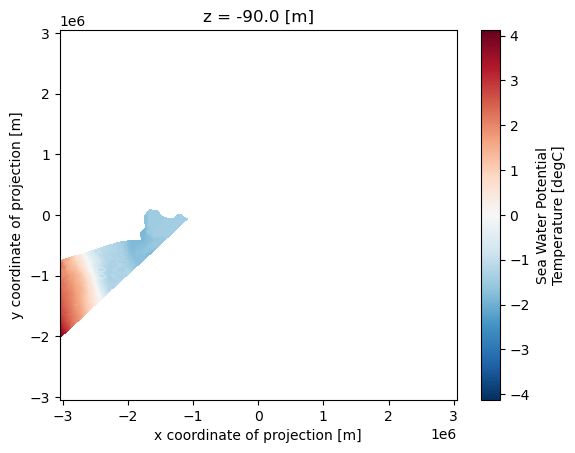

In [129]:
thetao.thetao.where(pig).sel(z=-100, method='nearest').plot()